In [11]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import protfasta
import metapredict

In [8]:
seq_dict = protfasta.read_fasta("../output/interpro_uniprot_evid_1_2.fasta")
seq_df = pd.DataFrame({"id" : seq_dict.keys(), "seq" : seq_dict.values()})
seq_df

,id,seq
0,tr|A0A0B4K6B8|A0A0B4K6B8_DROME Modifier of mdg...,MADDEQFSLCWNNFNTNLSAGFHESLCRGDLVDVSLAAEGQIVKAH...
1,tr|A0A0B4K7A6|A0A0B4K7A6_DROME Modifier of mdg...,MADDEQFSLCWNNFNTNLSAGFHESLCRGDLVDVSLAAEGQIVKAH...
2,sp|A0A5S9MMK5|FPEB1_CAEEL FLYWCH-type zinc fin...,MMTTTVQKNCWRLDQTMLGLEKPGSSDISSSSTDTSAISPISVSSM...
3,sp|Q4VC44|FWCH1_HUMAN FLYWCH-type zinc finger-...,MPLPEPSEQEGESVKAGQEPSPKPGTDVIPAAPRKPREFSKLVLLT...
4,sp|Q86B87|MMD4_DROME Modifier of mdg4 OS=Droso...,MADDEQFSLCWNNFNTNLSAGFHESLCRGDLVDVSLAAEGQIVKAH...
...,...,...
137431,tr|W8C846|W8C846_CERCA (Mediterranean fruit fl...,MNNITRLLANCTLNTTRCHLKYNAAALTAAIQLRGKCKVVVKPAPG...
137432,tr|W8CA25|W8CA25_CERCA (Mediterranean fruit fl...,MAGRPRRQAATRTAQIIEISDSEDDNSVSKNKRRRRDSSFSPPPTK...
137433,tr|W8QUS6|W8QUS6_MIMNO Cold shock domain prote...,MSDSEKQPEEKEEPKKNVIATKVTGTVKWFNVKSGYGFINRDDTKE...
137434,tr|X5CQH7|X5CQH7_9EUKA 30S plastidal ribosomal...,MSSARPLVLIASLLGASEALQSCHTRLVSSRVAATPRAAWALTMCD...


In [45]:
seq_df["net charge"] = seq_df["seq"].str.count('R') + seq_df["seq"].str.count('K') - seq_df["seq"].str.count('D') - seq_df["seq"].str.count('E')
seq_df["hydrophobics_prop"] = (seq_df["seq"].str.count('W') + seq_df["seq"].str.count('F') + seq_df["seq"].str.count('Y') + seq_df["seq"].str.count('L')) / seq_df["seq"].str.len()
seq_df

,id,seq,net charge,hydrophobics,percent_disorder,hydrophobics_prop
0,tr|A0A0B4K6B8|A0A0B4K6B8_DROME Modifier of mdg...,MADDEQFSLCWNNFNTNLSAGFHESLCRGDLVDVSLAAEGQIVKAH...,-9,51,69.311,0.106472
1,tr|A0A0B4K7A6|A0A0B4K7A6_DROME Modifier of mdg...,MADDEQFSLCWNNFNTNLSAGFHESLCRGDLVDVSLAAEGQIVKAH...,-14,56,63.922,0.109804
2,sp|A0A5S9MMK5|FPEB1_CAEEL FLYWCH-type zinc fin...,MMTTTVQKNCWRLDQTMLGLEKPGSSDISSSSTDTSAISPISVSSM...,6,57,67.494,0.128668
3,sp|Q4VC44|FWCH1_HUMAN FLYWCH-type zinc finger-...,MPLPEPSEQEGESVKAGQEPSPKPGTDVIPAAPRKPREFSKLVLLT...,10,116,52.793,0.162011
4,sp|Q86B87|MMD4_DROME Modifier of mdg4 OS=Droso...,MADDEQFSLCWNNFNTNLSAGFHESLCRGDLVDVSLAAEGQIVKAH...,-26,72,68.033,0.118033
...,...,...,...,...,...,...
137431,tr|W8C846|W8C846_CERCA (Mediterranean fruit fl...,MNNITRLLANCTLNTTRCHLKYNAAALTAAIQLRGKCKVVVKPAPG...,26,45,15.667,0.150000
137432,tr|W8CA25|W8CA25_CERCA (Mediterranean fruit fl...,MAGRPRRQAATRTAQIIEISDSEDDNSVSKNKRRRRDSSFSPPPTK...,14,136,22.045,0.144835
137433,tr|W8QUS6|W8QUS6_MIMNO Cold shock domain prote...,MSDSEKQPEEKEEPKKNVIATKVTGTVKWFNVKSGYGFINRDDTKE...,13,33,82.313,0.112245
137434,tr|X5CQH7|X5CQH7_9EUKA 30S plastidal ribosomal...,MSSARPLVLIASLLGASEALQSCHTRLVSSRVAATPRAAWALTMCD...,-9,42,36.474,0.127660


In [13]:
from joblib import Parallel, delayed
from tqdm import tqdm

# Define the function once (so joblib can pickle it)
def calc_percent_disorder(seq):
    return metapredict.percent_disorder(seq)

# Use joblib for parallelization and tqdm for progress
seq_df["percent_disorder"] = Parallel(
    n_jobs=-1  # Use all cores
)(
    delayed(calc_percent_disorder)(seq) 
    for seq in tqdm(seq_df["seq"], desc="Calculating disorder")
)


Calculating disorder: 100%|██████████| 137436/137436 [11:18<00:00, 202.57it/s]


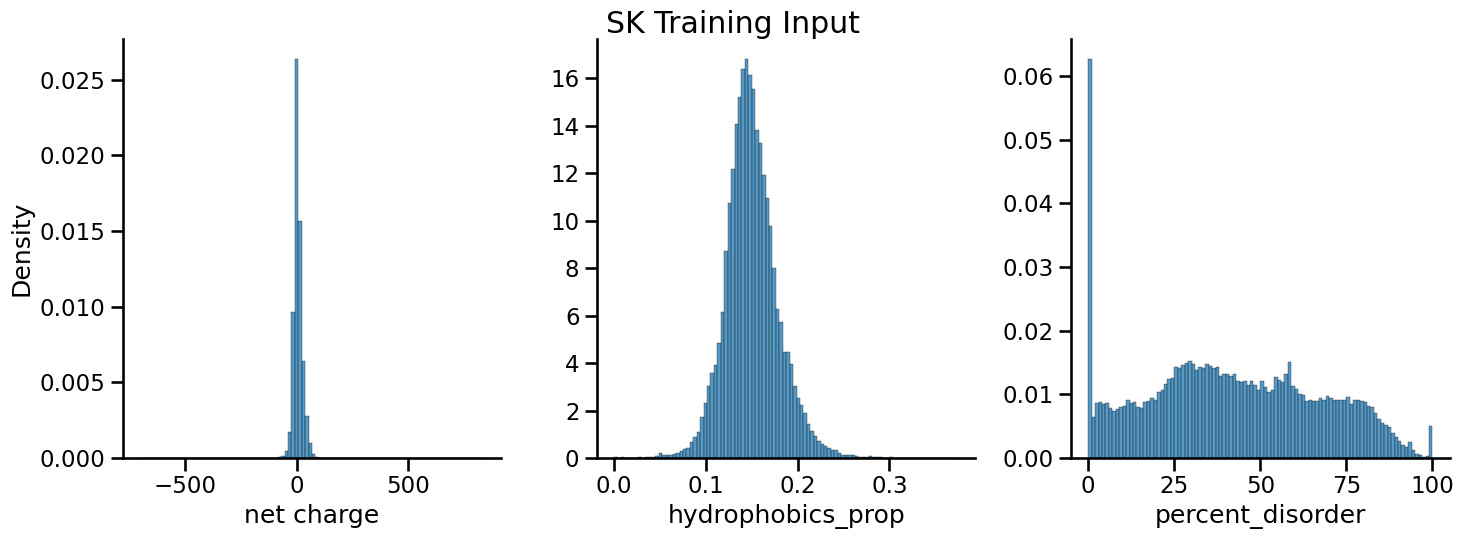

In [46]:
sns.set_context('talk')

fig, axs = plt.subplots(1, 3, figsize = (15, 6))

sns.histplot(seq_df["net charge"], ax = axs[0], stat = 'density', bins = 100)
sns.histplot(seq_df["hydrophobics_prop"], ax = axs[1], stat = 'density', bins = 100)
sns.histplot(seq_df["percent_disorder"], ax = axs[2], stat = 'density', bins = 100)

axs[1].set_ylabel("")
axs[2].set_ylabel("")
sns.despine()
fig.suptitle("SK Training Input", y = 0.91)
plt.tight_layout()
plt.show()

